In [6]:
# ============================================================
# 1. IMPORTS
# ============================================================

from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
# ============================================================
# 2. PROJECT PATH
# ============================================================

import sys
import importlib
from pathlib import Path

project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.data_pipeline
import src.events

importlib.reload(src.data_pipeline)
importlib.reload(src.events)

from src.data_pipeline import ModelDatasetBuilder
from src.events import SimpleEventDetector, CombinedEventDetector

In [8]:
# ============================================================
# 3. DATABASE PATH
# ============================================================

db_path = project_root / "NordPoool" / "data" / "thesis_database.db"

print("DB exists:", db_path.exists())
print("DB path:", db_path)

builder = ModelDatasetBuilder(db_path)

DB exists: True
DB path: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\data\thesis_database.db


In [9]:
# ============================================================
# 4. LOAD DATA
# ============================================================

df = builder.build_price_dataset(
    zones="NO1",
    start_date="2020-01-01",
    end_date="2020-12-31",
    add_time_features=True,
    lags=[1, 2, 24],
    target_horizon=1,
    include_volumes=True,
    # dropna=True Ignore rows with NaN values (due to lags)
)

df.head()

,price_id,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,year,month,day,day_of_week,price_value_lag_1,price_value_lag_2,price_value_lag_24,target
datetime,,,,,,,,,,,,,,,
2020-01-01 00:00:00,32,12,2020-01-01,0,31.77,4091.8,1819.6,2020,1,1,2,NaN,NaN,NaN,31.57
2020-01-01 01:00:00,52,12,2020-01-01,1,31.57,4021.3,1826.2,2020,1,1,2,31.77,NaN,NaN,31.28
2020-01-01 02:00:00,72,12,2020-01-01,2,31.28,3975.7,1836.8,2020,1,1,2,31.57,31.77,NaN,30.72
2020-01-01 03:00:00,92,12,2020-01-01,3,30.72,3993.6,1841.5,2020,1,1,2,31.28,31.57,NaN,30.27
2020-01-01 04:00:00,112,12,2020-01-01,4,30.27,4041.5,1798.0,2020,1,1,2,30.72,31.28,NaN,30.17


In [10]:
# ============================================================
# 5. DETECT PRICE EVENTS
# ============================================================

detector = SimpleEventDetector()
combined_detector = CombinedEventDetector()

df_events = detector.detect_price_events(df)
df_events = detector.detect_volume_events(df_events)
df_events = combined_detector.detect_combined_events(df_events)

print(df_events.shape)
df_events.head()

(8761, 58)


,price_id,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,year,month,day,...,sell_pressure_low_price,system_price_max,system_price_min,system_price_spread,price_separation,extreme_price_separation,system_price_median,price_deviation_from_system,zone_price_outlier,has_combined_event
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,32,12,2020-01-01,0,31.77,4091.8,1819.6,2020,1,1,...,False,31.77,31.77,0.0,False,False,31.77,0.0,False,False
2020-01-01 01:00:00,52,12,2020-01-01,1,31.57,4021.3,1826.2,2020,1,1,...,False,31.57,31.57,0.0,False,False,31.57,0.0,False,False
2020-01-01 02:00:00,72,12,2020-01-01,2,31.28,3975.7,1836.8,2020,1,1,...,False,31.28,31.28,0.0,False,False,31.28,0.0,False,False
2020-01-01 03:00:00,92,12,2020-01-01,3,30.72,3993.6,1841.5,2020,1,1,...,False,30.72,30.72,0.0,False,False,30.72,0.0,False,False
2020-01-01 04:00:00,112,12,2020-01-01,4,30.27,4041.5,1798.0,2020,1,1,...,False,30.27,30.27,0.0,False,False,30.27,0.0,False,False


In [22]:
# ============================================================
# 6. SELECT FEATURE SETS AND TARGET
# ============================================================

price_base_features = [
    "price_value",
    "year",
    "month",
    "day",
    "day_of_week",
]

lag_features = [
    "price_value_lag_1",
    "price_value_lag_2",
    "price_value_lag_24",
]

volume_base_features = [
    "buy_volume_value",
    "sell_volume_value",
]

price_event_features = [
    "low_price",
    "high_price",
    "price_spike",
    "extreme_price",
    "rapid_price_change",
    "price_ramp_up",
    "price_ramp_down",
    "high_volatility",
]

volume_event_features = [
    "high_demand",
    "low_demand",
    "high_generation",
    "low_generation",
    "strong_buy_pressure",
    "strong_sell_pressure",
    "buy_volume_spike",
    "sell_volume_spike",
]

combined_event_features = [
    "generation_surplus",
    "demand_pressure",
    "strong_demand_pressure",
    "strong_generation_pressure",
    "demand_driven_price_spike",
    "generation_driven_low_price",
    "scarcity_price_event",
    "oversupply_price_event",
    "buy_pressure_price_spike",
    "sell_pressure_low_price",
    "price_separation",
    "extreme_price_separation",
    "zone_price_outlier",
    "has_combined_event",
]

feature_sets = {
    # Baseline without event variables
    "baseline_price_lags": (
        price_base_features
        + lag_features
    ),

    # Baseline plus volume values, but no event flags
    "baseline_price_lags_volume": (
        price_base_features
        + lag_features
        + volume_base_features
    ),

    # Add only price events
    "price_events": (
        price_base_features
        + lag_features
        + volume_base_features
        + price_event_features
    ),

    # Add price and volume events
    "price_volume_events": (
        price_base_features
        + lag_features
        + volume_base_features
        + price_event_features
        + volume_event_features
    ),

    # Add combined events too
    "all_events": (
        price_base_features
        + lag_features
        + volume_base_features
        + price_event_features
        + volume_event_features
        + combined_event_features
    ),
}

df_model = df_events.dropna()

y = df_model["target"]

print("df_model shape:", df_model.shape)
print("y shape:", y.shape)

for set_name, cols in feature_sets.items():
    missing_cols = [col for col in cols if col not in df_model.columns]
    print(set_name, "n_features:", len(cols), "missing:", missing_cols)

df_model shape: (8736, 58)
y shape: (8736,)
baseline_price_lags n_features: 8 missing: []
baseline_price_lags_volume n_features: 10 missing: []
price_events n_features: 18 missing: []
price_volume_events n_features: 26 missing: []
all_events n_features: 40 missing: []


In [23]:
# ============================================================
# 7. TEMPORAL TRAIN / TEST SPLIT BY DATE
# ============================================================

train_end = "2020-11-30"
test_start = "2020-12-01"
test_end = "2020-12-08"

train_mask = df_model.index <= train_end
test_mask = (df_model.index >= test_start) & (df_model.index <= test_end)

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Train y:", y_train.shape)
print("Test y:", y_test.shape)
print("Train period:", y_train.index.min(), "to", y_train.index.max())
print("Test period:", y_test.index.min(), "to", y_test.index.max())

Train y: (7993,)
Test y: (169,)
Train period: 2020-01-02 00:00:00 to 2020-11-30 00:00:00
Test period: 2020-12-01 00:00:00 to 2020-12-08 00:00:00


In [24]:
# ============================================================
# 8. TRAIN MODELS FOR EACH FEATURE SET
# ============================================================

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "SVR": make_pipeline(
        StandardScaler(),
        SVR(kernel="rbf", C=10, epsilon=0.1)
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

experiment_results = []
experiment_predictions = {}
trained_models = {}

for feature_set_name, feature_cols in feature_sets.items():

    X = df_model[feature_cols]

    X_train = X.loc[train_mask]
    X_test = X.loc[test_mask]

    print(f"Training feature set: {feature_set_name}")
    print("X_train:", X_train.shape, "X_test:", X_test.shape)

    for model_name, model in models.items():
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        experiment_results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "n_features": len(feature_cols),
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
        })

        experiment_predictions[(feature_set_name, model_name)] = y_pred
        trained_models[(feature_set_name, model_name)] = model

print("All experiments trained successfully")

Training feature set: baseline_price_lags
X_train: (7993, 8) X_test: (169, 8)
Training feature set: baseline_price_lags_volume
X_train: (7993, 10) X_test: (169, 10)
Training feature set: price_events
X_train: (7993, 18) X_test: (169, 18)
Training feature set: price_volume_events
X_train: (7993, 26) X_test: (169, 26)
Training feature set: all_events
X_train: (7993, 40) X_test: (169, 40)
All experiments trained successfully


In [25]:
# ============================================================
# 9. EXPERIMENT RESULTS COMPARISON
# ============================================================

experiment_df = pd.DataFrame(experiment_results)

experiment_df = experiment_df.sort_values(
    ["RMSE", "MAE"],
    ascending=True
)

experiment_df

,feature_set,model,n_features,MAE,RMSE,R2
25,all_events,Ridge Regression,40,0.751935,1.072148,0.889481
24,all_events,Linear Regression,40,0.752324,1.072271,0.889456
19,price_volume_events,Ridge Regression,26,0.747069,1.072740,0.889359
18,price_volume_events,Linear Regression,26,0.747324,1.072952,0.889315
13,price_events,Ridge Regression,18,0.753460,1.082376,0.887362
12,price_events,Linear Regression,18,0.753753,1.082640,0.887307
6,baseline_price_lags_volume,Linear Regression,10,0.752211,1.118587,0.879700
7,baseline_price_lags_volume,Ridge Regression,10,0.752255,1.118646,0.879687
0,baseline_price_lags,Linear Regression,8,0.756247,1.123705,0.878596
1,baseline_price_lags,Ridge Regression,8,0.756292,1.123765,0.878583


In [26]:
# ============================================================
# 10. BEST MODEL PER FEATURE SET
# ============================================================

best_by_feature_set = (
    experiment_df
    .sort_values(["feature_set", "RMSE"])
    .groupby("feature_set")
    .head(1)
    .sort_values("RMSE")
)

best_by_feature_set

,feature_set,model,n_features,MAE,RMSE,R2
25,all_events,Ridge Regression,40,0.751935,1.072148,0.889481
19,price_volume_events,Ridge Regression,26,0.747069,1.072740,0.889359
13,price_events,Ridge Regression,18,0.753460,1.082376,0.887362
6,baseline_price_lags_volume,Linear Regression,10,0.752211,1.118587,0.879700
0,baseline_price_lags,Linear Regression,8,0.756247,1.123705,0.878596


In [27]:
# ============================================================
# 11. IMPROVEMENT VS BASELINE
# ============================================================

baseline_rmse = best_by_feature_set.loc[
    best_by_feature_set["feature_set"] == "baseline_price_lags",
    "RMSE"
].iloc[0]

impact_df = best_by_feature_set.copy()

impact_df["RMSE_improvement_abs"] = baseline_rmse - impact_df["RMSE"]

impact_df["RMSE_improvement_pct"] = (
    100 * impact_df["RMSE_improvement_abs"] / baseline_rmse
)

impact_df = impact_df.sort_values("RMSE")

impact_df

,feature_set,model,n_features,MAE,RMSE,R2,RMSE_improvement_abs,RMSE_improvement_pct
25,all_events,Ridge Regression,40,0.751935,1.072148,0.889481,0.051557,4.588141
19,price_volume_events,Ridge Regression,26,0.747069,1.072740,0.889359,0.050965,4.535418
13,price_events,Ridge Regression,18,0.753460,1.082376,0.887362,0.041329,3.677902
6,baseline_price_lags_volume,Linear Regression,10,0.752211,1.118587,0.879700,0.005118,0.455445
0,baseline_price_lags,Linear Regression,8,0.756247,1.123705,0.878596,0.000000,0.000000


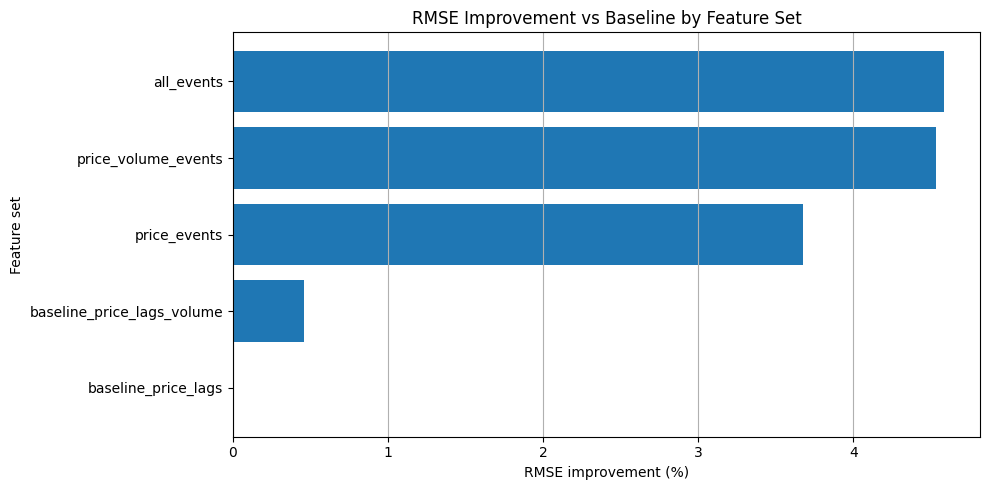

In [28]:
# ============================================================
# 12. PLOT FEATURE SET IMPACT
# ============================================================

plot_df = impact_df.sort_values("RMSE_improvement_pct")

plt.figure(figsize=(10, 5))

plt.barh(
    plot_df["feature_set"],
    plot_df["RMSE_improvement_pct"]
)

plt.title("RMSE Improvement vs Baseline by Feature Set")
plt.xlabel("RMSE improvement (%)")
plt.ylabel("Feature set")
plt.grid(True, axis="x")
plt.tight_layout()
plt.show()